# Eigenvalues and Eigenvectors

**Goal:** Understand what eigenvectors are, why they matter, and implement power iteration from scratch.

**Reference:** Mathematics for ML - Chapter 4 (Matrix Decompositions)

## What is an Eigenvector?

Think of a matrix $A$ as a **transformation** that stretches, rotates, or shears vectors.

When you multiply $A$ by a vector $\mathbf{v}$, the result is usually a **different direction**.

But some special vectors **don't change direction** — they only get scaled. These are called **eigenvectors**.

$$A \mathbf{v} = \lambda \mathbf{v}$$

- $\mathbf{v}$: eigenvector (direction that stays the same)
- $\lambda$: eigenvalue (how much it scales)

**Geometric picture:**
- $\lambda > 1$: vector stretches
- $0 < \lambda < 1$: vector shrinks
- $\lambda < 0$: vector flips direction
- $\lambda = 0$: vector collapses to zero (matrix is singular)

## Example: A Simple 2x2 Matrix

$$A = \begin{bmatrix} 2 & 0 \\ 0 & 3 \end{bmatrix}$$

This matrix stretches:
- $x$-axis by factor 2
- $y$-axis by factor 3

**Eigenvectors and eigenvalues:**

$$A \begin{bmatrix} 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 2 \\ 0 \end{bmatrix} = 2 \begin{bmatrix} 1 \\ 0 \end{bmatrix} \quad \Rightarrow \quad \lambda_1 = 2, \; \mathbf{v}_1 = \begin{bmatrix} 1 \\ 0 \end{bmatrix}$$

$$A \begin{bmatrix} 0 \\ 1 \end{bmatrix} = \begin{bmatrix} 0 \\ 3 \end{bmatrix} = 3 \begin{bmatrix} 0 \\ 1 \end{bmatrix} \quad \Rightarrow \quad \lambda_2 = 3, \; \mathbf{v}_2 = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$$

So the eigenvectors are along the axes, and eigenvalues are the scaling factors.

## A Non-Trivial Example

$$A = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix}$$

This matrix isn't diagonal, so finding eigenvectors isn't obvious.

Let's try $\mathbf{v} = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$:

$$A \mathbf{v} = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 1 \\ 1 \end{bmatrix} = \begin{bmatrix} 3 \\ 3 \end{bmatrix} = 3 \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$

So $\mathbf{v} = [1, 1]$ is an eigenvector with $\lambda = 3$.

Now try $\mathbf{v} = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$:

$$A \mathbf{v} = \begin{bmatrix} 2 & 1 \\ 1 & 2 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \end{bmatrix} = \begin{bmatrix} 1 \\ -1 \end{bmatrix} = 1 \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

So $\mathbf{v} = [1, -1]$ is an eigenvector with $\lambda = 1$.

**Interesting:** the eigenvectors form a new coordinate system where $A$ just scales.

## Finding Eigenvalues: The Characteristic Equation

Starting from:

$$A \mathbf{v} = \lambda \mathbf{v}$$

Move everything to one side:

$$A \mathbf{v} - \lambda \mathbf{v} = \mathbf{0}$$

Factor out $\mathbf{v}$ (with identity matrix):

$$(A - \lambda I) \mathbf{v} = \mathbf{0}$$

For this to have a **non-zero solution** $\mathbf{v}$, the matrix $(A - \lambda I)$ must be **singular**:

$$\det(A - \lambda I) = 0$$

This is the **characteristic equation**. Solving it gives eigenvalues.

**For 2x2:**
$$\det \begin{bmatrix} a - \lambda & b \\ c & d - \lambda \end{bmatrix} = (a - \lambda)(d - \lambda) - bc = 0$$

This is a quadratic in $\lambda$. For $n \times n$, it's a degree-$n$ polynomial.

In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [7]:
def eigenvalues_2x2(A):
    """
    Compute eigenvalues of a 2x2 matrix.
    Solves: lambda^2 - trace(A)*lambda + det(A) = 0
    """
    a, b = A[0]
    c, d = A[1]
    trace = a + d
    det = a * d - b * c
    # Quadratic formula: lambda = (trace ± sqrt(trace^2 - 4*det)) / 2
    discriminant = trace ** 2 - 4 * det
    if discriminant < 0:
        return None  # complex eigenvalues
    sqrt_disc = discriminant ** 0.5
    lambda1 = (trace + sqrt_disc) / 2
    lambda2 = (trace - sqrt_disc) / 2
    return lambda1, lambda2


# Test
A = [[2, 1], [1, 2]]
print("My:   ", eigenvalues_2x2(A))
print("NumPy:", np.linalg.eigvals(A))

My:    (3.0, 1.0)
NumPy: [3. 1.]


## Why `trace` and `det`?

For a 2x2 matrix:
$$\det(A - \lambda I) = (a - \lambda)(d - \lambda) - bc$$
$$= \lambda^2 - (a + d)\lambda + (ad - bc)$$
$$= \lambda^2 - \text{tr}(A) \lambda + \det(A)$$

So:
$$\lambda = \frac{\text{tr}(A) \pm \sqrt{\text{tr}(A)^2 - 4 \det(A)}}{2}$$

**Nice facts:**
- $\lambda_1 + \lambda_2 = \text{tr}(A)$ (sum of eigenvalues = trace)
- $\lambda_1 \cdot \lambda_2 = \det(A)$ (product of eigenvalues = determinant)

## Power Iteration: Finding the Dominant Eigenvector

For large matrices, computing all eigenvalues is expensive. But often we only need the **largest** one (the dominant eigenvalue).

**Power iteration** is a simple algorithm:

1. Start with a random vector $\mathbf{v}$
2. Repeatedly multiply: $\mathbf{v} \leftarrow A \mathbf{v}$
3. Normalize $\mathbf{v}$ each step to avoid overflow
4. After many steps, $\mathbf{v}$ converges to the dominant eigenvector

**Why does it work?**

Any vector can be written as a combination of eigenvectors:
$$\mathbf{v} = c_1 \mathbf{v}_1 + c_2 \mathbf{v}_2 + \dots + c_n \mathbf{v}_n$$

After $k$ multiplications:
$$A^k \mathbf{v} = c_1 \lambda_1^k \mathbf{v}_1 + c_2 \lambda_2^k \mathbf{v}_2 + \dots$$

If $|\lambda_1| > |\lambda_2| \geq \dots$, then $\lambda_1^k$ dominates as $k \to \infty$.

The component along $\mathbf{v}_1$ grows fastest, so $\mathbf{v}$ aligns with $\mathbf{v}_1$.

In [8]:
def power_iteration(A, num_iters=100, tol=1e-10):
    """
    Find the dominant eigenvalue and eigenvector of A using power iteration.
    Returns (eigenvalue, eigenvector).
    """
    n = len(A)
    #  random vector
    v = [1.0] * n  

    for it in range(num_iters):
        # Multiply A by v
        v_new = [sum(A[i][j] * v[j] for j in range(n)) for i in range(n)]

        # Compute the norm (length) of the new vector
        norm = sum(x ** 2 for x in v_new) ** 0.5
        if norm < 1e-12:
            return 0, v  # eigenvalue is 0

        # Normalize
        v_new = [x / norm for x in v_new]

        # Check convergence
        diff = sum((v_new[i] - v[i]) ** 2 for i in range(n)) ** 0.5
        v = v_new
        if diff < tol:
            print(f"Converged after {it + 1} iterations")
            break

    # Compute eigenvalue using Rayleigh quotient: lambda = v^T A v / v^T v
    Av = [sum(A[i][j] * v[j] for j in range(n)) for i in range(n)]
    eigenvalue = sum(v[i] * Av[i] for i in range(n)) / sum(x ** 2 for x in v)
    return eigenvalue, v


# Test
A = [[4, 1], [2, 3]]
val, vec = power_iteration(A)
print(f"My eigenvalue:    {val:.6f}")
print(f"My eigenvector:   {[f'{x:.6f}' for x in vec]}")
print()
print(f"NumPy eigenvalues: {np.linalg.eigvals(A)}")
print(f"NumPy eigenvectors:\n{np.linalg.eig(A)[1]}")

Converged after 2 iterations
My eigenvalue:    5.000000
My eigenvector:   ['0.707107', '0.707107']

NumPy eigenvalues: [5. 2.]
NumPy eigenvectors:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


## Rayleigh Quotient

Once we have an eigenvector approximation $\mathbf{v}$, we can compute the eigenvalue:

$$\lambda = \frac{\mathbf{v}^T A \mathbf{v}}{\mathbf{v}^T \mathbf{v}}$$

If $\mathbf{v}$ is normalized ($\|\mathbf{v}\| = 1$), then $\mathbf{v}^T \mathbf{v} = 1$, so:

$$\lambda = \mathbf{v}^T A \mathbf{v}$$

This is called the **Rayleigh quotient**. It gives a good estimate of the eigenvalue even when $\mathbf{v}$ is just approximately correct.

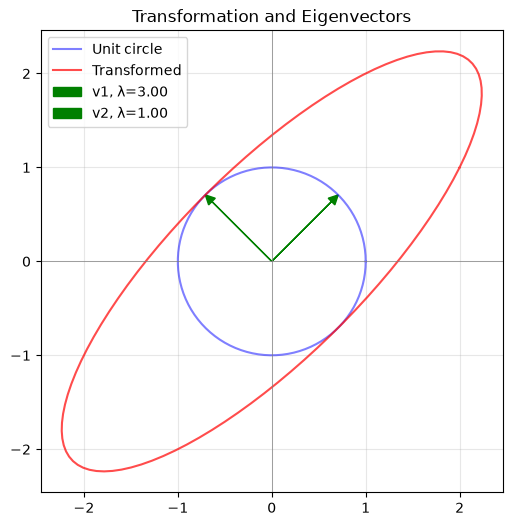

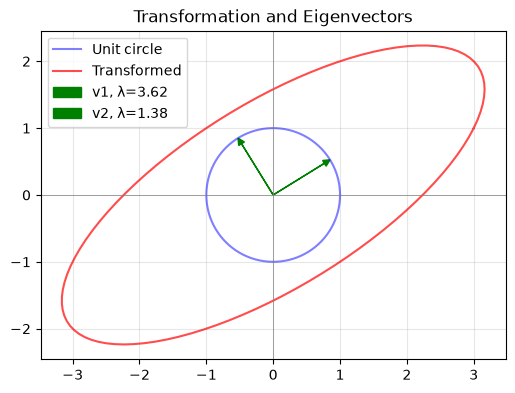

In [9]:
def plot_eigenvectors(A):
    """Plot how A transforms the unit circle, and show eigenvectors."""
    theta = np.linspace(0, 2 * np.pi, 100)
    circle = np.array([np.cos(theta), np.sin(theta)])

    # Transform each point on the circle
    transformed = np.array(A) @ circle

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(circle[0], circle[1], 'b-', label='Unit circle', alpha=0.5)
    ax.plot(transformed[0], transformed[1], 'r-', label='Transformed', alpha=0.7)

    # Draw eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(A)
    for i, (lam, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
        ax.arrow(0, 0, vec[0], vec[1], head_width=0.1, head_length=0.1,
                 color='green', length_includes_head=True,
                 label=f'v{i+1}, λ={lam:.2f}')

    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_aspect('equal')
    ax.set_title("Transformation and Eigenvectors")
    plt.show()


plot_eigenvectors([[2, 1], [1, 2]])
plot_eigenvectors([[3, 1], [1, 2]])